### [ 주제 : AutoEncoder 학습 - 정상 소리만으로 ]
- **Part A. 데이터 준비** (로드 → 분리 → 정규화 → Dataset/DataLoader)
- **Part B. 모델 정의 + 학습**
- **Part C. loss 곡선, 복원 실험, 모델 저장**

> **완료 기준** : ① loss가 내려가다 평평해짐 ② 이상 복원 오차 > 정상 복원 오차

**📍 전체 코드 흐름 지도 (shape 따라가기)** — 헷갈리면 `print(변수.shape)` 찍고 여기서 위치 찾기

```
[파일] id_00_normal.npy              id_00_abnormal.npy
          │ np.load                     │ np.load
          ▼                             ▼
     normalNP (1068, 64, 313)      abnormalNP (356, 64, 313)
          │ 셔플 후 8:2 분리             │
    ┌─────┴──────┐                      │
    ▼            ▼                      ▼
 trainNP      test_normalNP        test_abnormalNP
 (854,64,313) (214,64,313)         (356,64,313)
    │              └─ 학습엔 안 씀, Part C에서 사용 ─┘
    │ 0~1 정규화 (기준은 trainNP에서만)
    ▼
 MelDataset : reshape → (854, 20032)     # 그림을 한 줄로 펴기
    │ DataLoader가 32개씩 묶어서 꺼내줌
    ▼
 배치 feature (32, 20032)
    │ model(feature)
    │   encoder : (32, 20032) → (32, 512) → (32, 64)     # 압축
    │   decoder : (32, 64) → (32, 512) → (32, 20032)     # 복원
    ▼
 out (32, 20032)
    │ loss = MSE(out, feature)           # 복원본 vs 원본 비교 → 숫자 1개
    ▼
 backward() → step() : 가중치 조금 수정
 (27배치 × 30에포크 = 810번 반복하면 학습 끝)
```

**[0] 사전준비**
- 모듈 로딩, 학습 설정, models 폴더 생성

In [1]:
## 모듈 로딩
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [2]:
## => 학습 설정
SAVE_DIR = '../data/processed/slider'
MODEL_DIR = '../models'
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'학습 장치 : {DEVICE}')

os.makedirs(MODEL_DIR,exist_ok=True)

학습 장치 : cuda


**[Part A] 데이터 준비**

핵심 원칙 두 가지
1. **이상 데이터는 학습에 한 개도 안 쓴다** (전부 테스트용)
2. **정규화 기준(MIN/MAX)은 학습 데이터에서만 구한다** (테스트 정보를 미리 보면 평가 오염)

In [15]:
## => 정상/이상 npy 로드 후 정상을 학습/테스트로 분리
normalNP = np.load(f'{SAVE_DIR}/id_00_normal.npy')
abnormalNP = np.load(f'{SAVE_DIR}/id_00_abnormal.npy')

np.random.seed(42)
idx = np.random.permutation(len(normalNP))
TRAIN_NUM = int(len(normalNP) * TRAIN_RATIO)

trainNP = normalNP[idx[:TRAIN_NUM]]
test_normalNP = normalNP[idx[TRAIN_NUM:]]

print(f'학습(정상)   : {trainNP.shape}')
print(f'테스트(정상)   : {test_normalNP.shape}')
print(f'테스트(이상)   : {abnormalNP.shape}')

학습(정상)   : (854, 64, 313)
테스트(정상)   : (214, 64, 313)
테스트(이상)   : (356, 64, 313)


In [4]:
## => 0~1 정규화 : 기준(MIN, MAX)은 반드시 학습 데이터에서만!
MIN = trainNP.min()
MAX = trainNP.max()

trainNP       = (trainNP - MIN) / (MAX - MIN)
test_normalNP = (test_normalNP - MIN) / (MAX - MIN)
test_abnormalNP = (abnormalNP - MIN) / (MAX - MIN) 

print(f'학습 데이터 범위 : {trainNP.min():.4f} ~ {trainNP.max():.4f}')

학습 데이터 범위 : 0.0000 ~ 1.0000


In [5]:
## -> 클래스 기능 : 멜 스펙트로그램 배열을 AutoEncoder 학습용으로 제공
## -> 클래스 이름 : MelDataset (부모 : Dataset)
## -> 필수 메서드 : __init__, __len__, __getitem__
class MelDataset(Dataset):
    def __init__(self,dataNP):
        super().__init__()
        self.data = dataNP.reshape(len(dataNP), -1)
        self.rows = len(dataNP)
        
    def __len__(self):
        return self.rows
    
    def __getitem__(self, index):
        return torch.FloatTensor(self.data[index])

In [6]:
## => Dataset, DataLoader 생성
trainDS = MelDataset(trainNP)
trainDL = DataLoader(trainDS, batch_size=BATCH_SIZE, shuffle=True)

print(f'학습 샘플 : {len(trainDS)}개, 배치 : {len(trainDL)}개')


학습 샘플 : 854개, 배치 : 27개


**[Part B] 모델 정의 + 학습**

구조 : `20032 → 512 → 64 → 512 → 20032`

- encoder : 20032차원을 64차원까지 **압축** (중요한 특징만 남김)
- decoder : 64차원에서 다시 20032차원으로 **복원**
- 정상만 학습했으니, 이상 소리는 압축~복원 과정에서 정보가 깨진다 → 복원 오차 큼

In [7]:
## -> 클래스 기능 : 입력을 압축(encoder)했다가 복원(decoder)하는 AutoEncoder
## -> 클래스 이름 : AutoEncoder (부모 : nn.Module)
## -> 구조 : 20032 -> 512 -> 64 -> 512 -> 20032
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(20032, 512), nn.ReLU(),
            nn.Linear(512, 64), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 512), nn.ReLU(),
            nn.Linear(512, 20032), nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out
model = AutoEncoder().to(DEVICE)
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=20032, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=20032, bias=True)
    (3): Sigmoid()
  )
)


In [8]:
## => 학습 준비 + 학습 루프
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

loss_history = []
for epoch in range(EPOCHS):
    model.train()
    loss_total = []
    for feature in trainDL:
        feature = feature.to(DEVICE)
        out = model(feature)
        
        optimizer.zero_grad()
        loss = loss_fn(out, feature)
        loss.backward()
        optimizer.step()
        
        loss_total.append(loss.item())
        
    epoch_loss = sum(loss_total) / len(loss_total)
    loss_history.append(epoch_loss)
    print(f'[{epoch+1:2d}/{EPOCHS}] loss : {epoch_loss:.6f}')

[ 1/30] loss : 0.007155
[ 2/30] loss : 0.003016
[ 3/30] loss : 0.002543
[ 4/30] loss : 0.002373
[ 5/30] loss : 0.002230
[ 6/30] loss : 0.002056
[ 7/30] loss : 0.001987
[ 8/30] loss : 0.001803
[ 9/30] loss : 0.001745
[10/30] loss : 0.001685
[11/30] loss : 0.001745
[12/30] loss : 0.001705
[13/30] loss : 0.001692
[14/30] loss : 0.001692
[15/30] loss : 0.001659
[16/30] loss : 0.001644
[17/30] loss : 0.001634
[18/30] loss : 0.001600
[19/30] loss : 0.001591
[20/30] loss : 0.001644
[21/30] loss : 0.001585
[22/30] loss : 0.001568
[23/30] loss : 0.001517
[24/30] loss : 0.001499
[25/30] loss : 0.001491
[26/30] loss : 0.001470
[27/30] loss : 0.001452
[28/30] loss : 0.001468
[29/30] loss : 0.001448
[30/30] loss : 0.001387


**[Part C] 확인 + 저장**

확인할 것 : ① loss 곡선이 내려가다 평평해지는지 ② 이상 복원 오차 > 정상 복원 오차

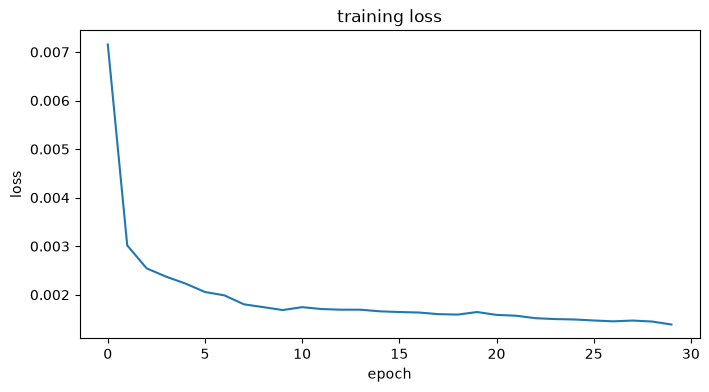

In [9]:
## => 학습 곡선 그리기
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title('training loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()


In [10]:
## => 복원 실험 : 정상은 잘 복원되고 이상은 잘 안 되는지
model.eval()
with torch.no_grad():
    x_normal = torch.FloatTensor(test_normalNP[0].reshape(1, -1)).to(DEVICE)
    x_abnormal = torch.FloatTensor(test_abnormalNP[0].reshape(1, -1)).to(DEVICE)
    out_normal   = model(x_normal)
    out_abnormal = model(x_abnormal)

err_normal   = ((x_normal - out_normal)**2).mean().item()
err_abnormal = ((x_abnormal - out_abnormal)**2).mean().item()

print(f'정상 복원 오차 : {err_normal:.6f}')
print(f'이상 복원 오차 : {err_abnormal:.6f}')

정상 복원 오차 : 0.001727
이상 복원 오차 : 0.002912


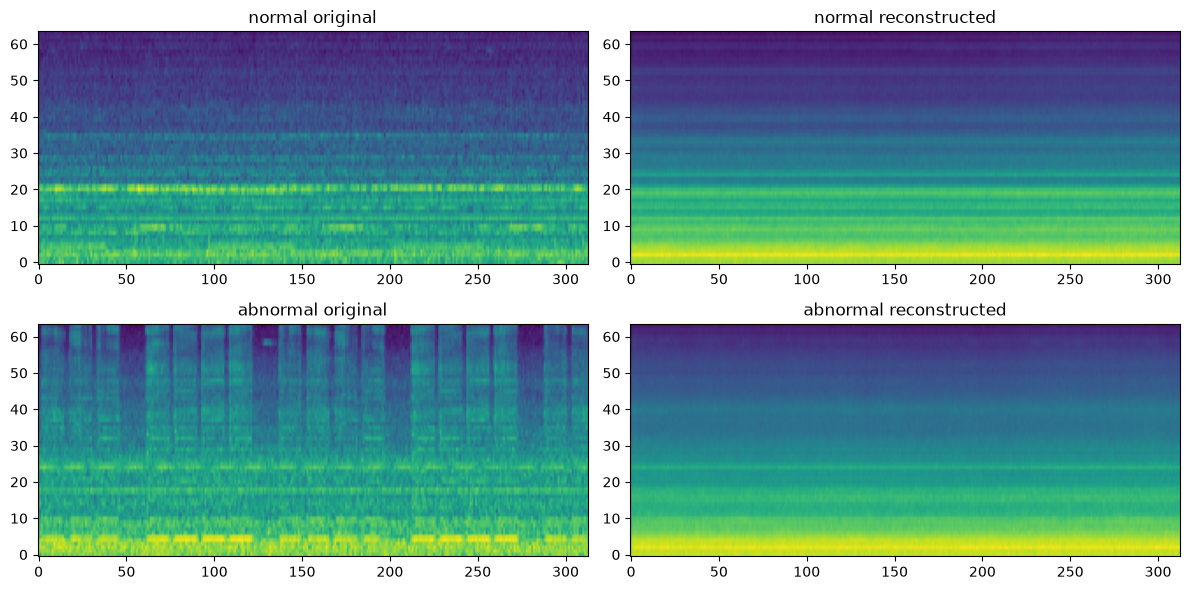

In [13]:
## => 원본 vs 복원 그림 비교 (2x2 : 윗줄 정상, 아랫줄 이상 / 왼쪽 원본, 오른쪽 복원)
plt.figure(figsize=(12,6))
plt.subplot(2, 2, 1)
plt.imshow(test_normalNP[0],aspect='auto',origin='lower')
plt.title('normal original')
plt.subplot(2, 2, 2)
plt.imshow(out_normal.cpu().numpy().reshape(64, 313), aspect='auto', origin='lower')
plt.title('normal reconstructed')
plt.subplot(2, 2, 3)
plt.imshow(test_abnormalNP[0],aspect='auto', origin='lower')
plt.title('abnormal original')
plt.subplot(2, 2, 4)
plt.imshow(out_abnormal.cpu().numpy().reshape(64, 313),aspect='auto', origin='lower')
plt.title('abnormal reconstructed')
plt.tight_layout()
plt.show()

In [14]:
## => 모델 저장 : 다른 모델을 실험해도 이 결과는 남는다
MODEL_PATH = f'{MODEL_DIR}/ae_id00_v1.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f'저장 확인 : {os.path.exists(MODEL_PATH)}')

저장 확인 : True


## 다음 단계

- 완료 기준 2개가 확인되면 3단계(모델 학습) 완료
- 다음 노트북(04)에서는 **테스트 전체의 복원 오차 분포**로 AUC를 계산하고 판정 임계값을 정한다
